Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Importing Scikit-Learn modules for Machine Learning

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc

Loading the Dataset

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


Feature Selection & Train/Test Split

In [4]:
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Feature Scaling

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Training the Random Forest Model

In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

Making Predictions & Evaluating Accuracy

In [7]:
y_pred = rf_model.predict(X_test_scaled)

y_prob = rf_model.predict_proba(X_test_scaled)[:, 1]

print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 89.00%

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.89      0.91        63
           1       0.82      0.89      0.86        37

    accuracy                           0.89       100
   macro avg       0.88      0.89      0.88       100
weighted avg       0.89      0.89      0.89       100



Confusion Matrix

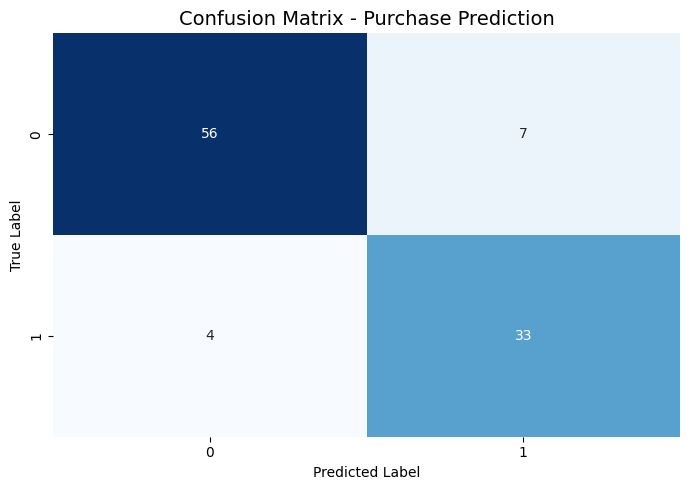

In [8]:
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)

plt.title('Confusion Matrix - Purchase Prediction', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

ROC Curve

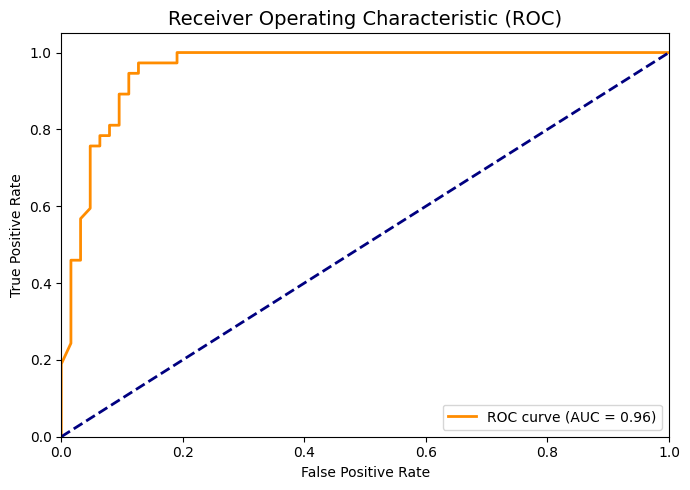

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Baseline

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Feature Importance

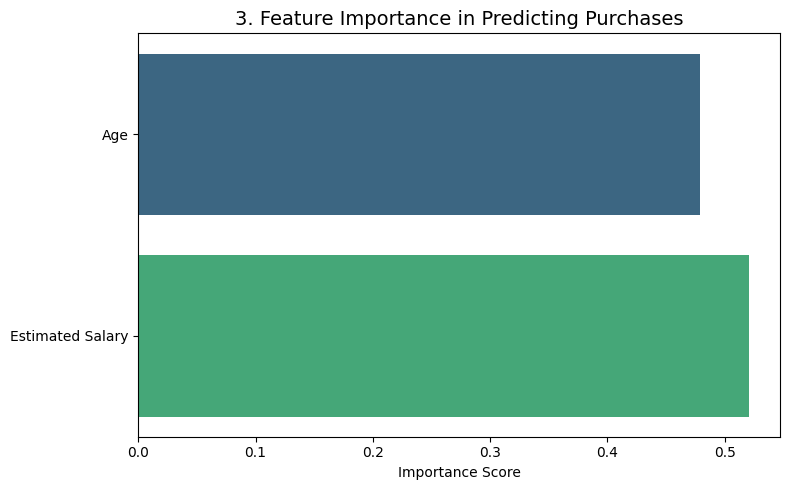

In [10]:
plt.figure(figsize=(8, 5))
importances = rf_model.feature_importances_

sns.barplot(x=importances, y=['Age', 'Estimated Salary'], palette='viridis', hue=['Age', 'Estimated Salary'], legend=False)
plt.title('3. Feature Importance in Predicting Purchases', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

Random Forest Decision Boundary

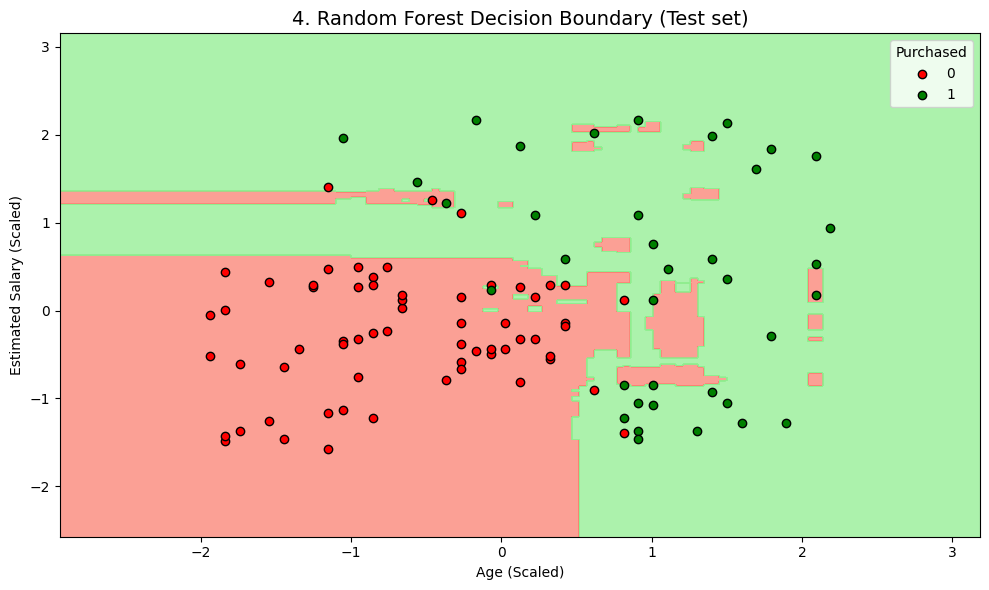

In [12]:
from matplotlib.colors import ListedColormap

X_set, y_set = X_test_scaled, y_test.values
X1, X2 = np.meshgrid(np.arange(start=X_set[:, 0].min() - 1, stop=X_set[:, 0].max() + 1, step=0.01),
                     np.arange(start=X_set[:, 1].min() - 1, stop=X_set[:, 1].max() + 1, step=0.01))

plt.figure(figsize=(10, 6))
plt.contourf(X1, X2, rf_model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha=0.75, cmap=ListedColormap(('salmon', 'lightgreen')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                color=ListedColormap(('red', 'green'))(i), label=j, edgecolor='k')

plt.title('4. Random Forest Decision Boundary (Test set)', fontsize=14)
plt.xlabel('Age (Scaled)')
plt.ylabel('Estimated Salary (Scaled)')
plt.legend(title='Purchased')
plt.tight_layout()
plt.show()